Device chosen: cpu
['adx', 'aroon', 'aroon_down', 'aroon_up', 'atr', 'bb_bbh', 'bb_bbl', 'bb_bbm', 'close', 'cmf', 'ema20', 'ema50', 'kch_high', 'kch_low', 'kch_mid', 'macd_diff', 'mfi', 'pocket_pivot', 'rel_close', 'rel_high', 'rel_low', 'rel_open', 'roc', 'rsi', 'sma', 'squeeze', 'tsi', 'vwap']


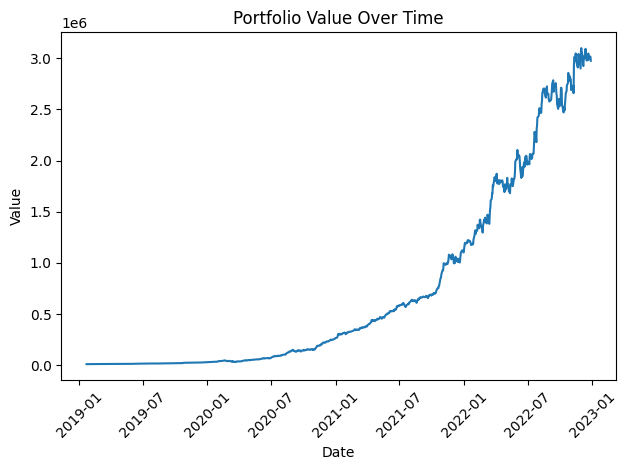

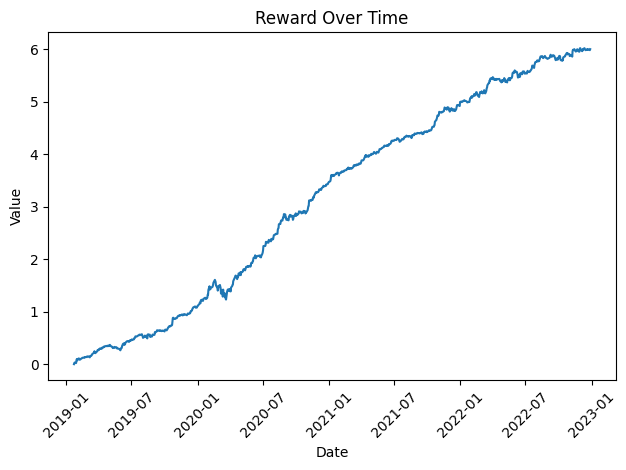

In [5]:
from td3.config.app_config import AppConfig
from td3.data.data_processor import DataProcessor
from td3.models.td3 import TD3
from td3.environment.portfolio import PortfolioEnv
from td3.utils.logger import LoggerFactory
import matplotlib.pyplot as plt

logger = LoggerFactory.create_logger(__name__)

MODEL_PATH = "simulations/run_2026-01-25_20-01-53/model/td3_model.pth"
app_config = AppConfig(
    start_date="2019-01-21",
    end_date="2023-01-01",
    learning_start_episode=None,
    number_of_episodes=1,
)

if __name__ == "__main__":
    dp = DataProcessor(data_dir=app_config.data_dir)
    df = dp.load_panel(
        tickers=app_config.ticker_config.tickers,
        start=app_config.start_date,
        end=app_config.end_date,
    )

    df_features = df.drop(columns=app_config.filter_out, level=1)
    dates = df_features.index.unique().to_list()
    df_prices = df.loc[:, (slice(None), ['close'])]
    data_3d_features, _, tickers, features = dp.to_3d(df_features)
    data_3d_prices, _, _, _ = dp.to_3d(df_prices)

    print(features)

    env = PortfolioEnv(
        features=data_3d_features,
        prices=data_3d_prices,
        tickers=tickers,
        app_config=app_config,
    )

    action_dim = env.action_space.shape[0]
    state_dim = int(env.observation_space.shape[0])
    td3_agent = TD3(
        state_dim=state_dim,
        action_dim=action_dim,
        noise_anneal_episodes=app_config.noise_anneal_episodes,
        learning_starts=app_config.learning_start_episode,
    )

    td3_agent.load_model(MODEL_PATH)
    all_rewards = []
    all_portfolio_values = []
    all_weights = []
    episode_reward = 0.0
    for episode in range(app_config.number_of_episodes):
        state = env.reset(options={"episode_number": episode})
        done = False

        while True:
            if done:
                break

            td3_agent.set_episode(episode)
            action, noisy_logits = td3_agent.select_action(state, 1, None, None, False)
            new_state, reward_val, done, trunc, info = env.step(action)
            state = new_state

            episode_reward += float(reward_val)
            all_rewards.append(episode_reward)
            all_portfolio_values.append(env.portfolio_value.curr)
            all_weights.append(env.weights.curr)

    n = min(len(all_portfolio_values), len(dates))
    all_portfolio_values = all_portfolio_values[:n]
    dates = dates[:n]

    plt.plot(dates, all_portfolio_values)
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.title("Portfolio Value Over Time")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.plot(dates, all_rewards)
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.title("Reward Over Time")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

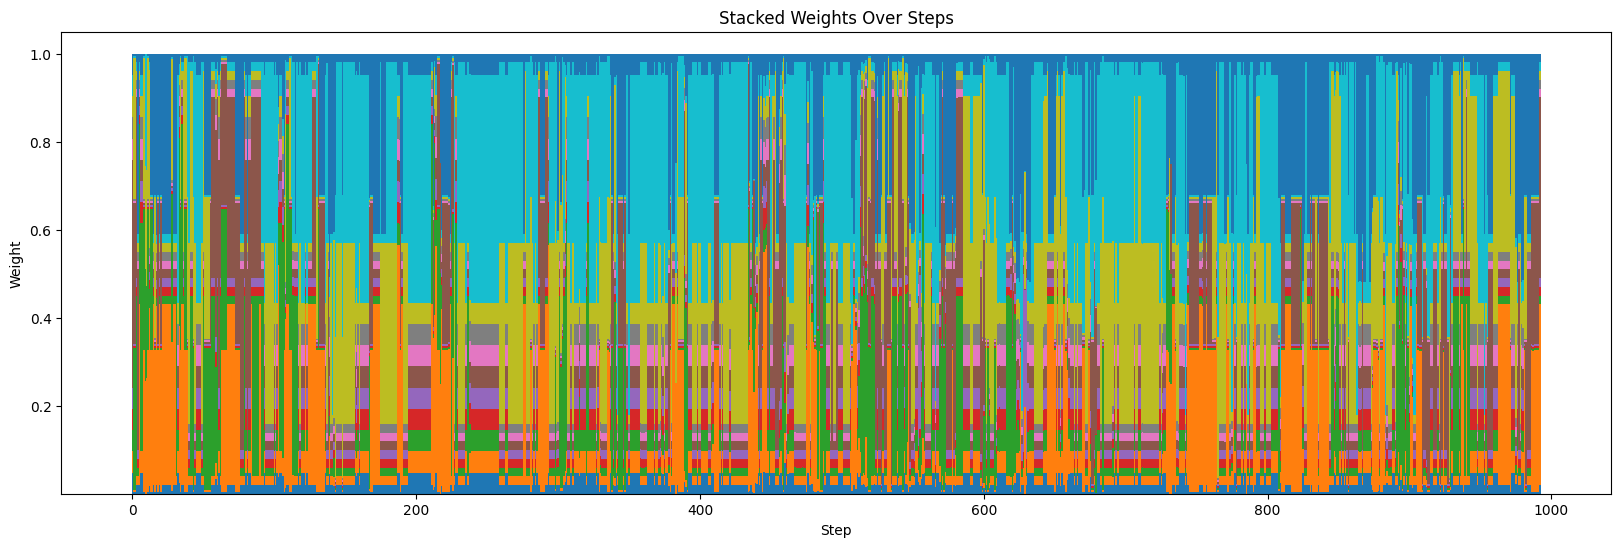

In [6]:
import numpy as np
import matplotlib.pyplot as plt

num_steps = len(all_weights)
num_assets = len(all_weights[0])
weights_array = np.array(all_weights)

x = np.arange(num_steps)
bottom = np.zeros(num_steps)

plt.figure(figsize=(20, 6))

for i in range(num_assets):
    plt.bar(x, weights_array[:, i], bottom=bottom, width=1.0)
    bottom += weights_array[:, i]

plt.xlabel("Step")
plt.ylabel("Weight")
plt.title("Stacked Weights Over Steps")
plt.show()

In [7]:
import csv

with open("weights.csv", "w", newline="") as f:
    writer = csv.writer(f)

    writer.writerow(["date", "Cash"] + tickers)

    for date, weights in zip(dates, all_weights):
        writer.writerow([date.strftime("%Y-%m-%d")] + [float(w) for w in weights])